# Capitalisations à prendre
## Méga-capitalisations (groupe contrôle, 12)
- AAPL
- MSFT


## Intermédiaires

In [6]:
import yfinance as yf
import duckdb
import pandas as pd
import numpy as np
import datetime
import requests
from time import sleep
import matplotlib.pyplot as plt
import finnhub 
from dotenv import load_dotenv
import os
from fmp_python.fmp import FMP
from requests import JSONDecodeError
import random as rd


In [ ]:
# CORRECTION


def init_db(db_path):
    with duckdb.connect(db_path) as con:
        # create table
        con.execute("""
                    CREATE TABLE IF NOT EXISTS prices ( 
                    date DATE NOT NULL, 
                    ticker VARCHAR NOT NULL, 
                    adj_close DOUBLE,
                    close DOUBLE, 
                    high DOUBLE, 
                    low DOUBLE,  
                    open DOUBLE, 
                    volume BIGINT,
                    PRIMARY KEY (date, ticker)
                    );
                    """
        )


def fetch_prices(tickers, start, end):
    frames = []

    for ticker in tickers:
        try:
            rows = yf.download(ticker,start=start, end=end, auto_adjust=False).reset_index()
            if rows.empty:
                print(f"[skip] {ticker}: no data")
                continue
            
            # Map columns correctly
            if isinstance(rows.columns, pd.MultiIndex):
                rows.columns = rows.columns.get_level_values(0)
            rows['ticker'] = ticker
            rows = rows.rename(columns={
                'index': 'date', 'Ticker': 'ticker', 'Open': 'open', 'Close': 'close', 'High': 'high', 'Low': 'low', 'Adj Close': 'adj_close', 'Volume': 'volume'
            })
            rows['date'] = rows['date'].dt.tz_localize('America/New_York').dt.date
            # Remove NA values if any
            prev_lines = rows.shape[0]
            rows = rows.dropna(subset=['close', 'adj_close'])
            if rows.shape[0] < prev_lines:
                print(f'Removed {rows.shape[0] - prev_lines} lines due to NA values in close/adj_close')

            frames.append(rows)
        except Exception as e:
            print(f'An error occurred for ticker {ticker}: {e}. \n Continuing...')
            continue
        finally:
            sleep(0.3)
    if not frames:
        print("No data fetched for any ticker.")
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

def store_prices(df, db_path):
    with duckdb.connect(db_path) as con:
        con.register('my_df', df)
        con.execute('INSERT OR REPLACE INTO prices (date, ticker, adj_close, close, high, low, open, volume) SELECT date, ticker, adj_close, close, high, low, open, volume FROM my_df')
    
def query_prices(ticker, db_path) -> pd.DataFrame:
    with duckdb.connect(db_path) as con:
        query = 'SELECT * FROM prices WHERE ticker = ?'
        output = con.execute(query, [ticker]).fetchdf()
        if output.empty:
            print(f'Specified ticker {ticker} returned empty')
    return output

In [52]:
# CORRECTION


def init_prices_db(db_path):
    with duckdb.connect(db_path) as con:
        # create table
        con.execute("""
                    CREATE TABLE IF NOT EXISTS prices ( 
                    date DATE NOT NULL, 
                    ticker VARCHAR NOT NULL, 
                    adj_close DOUBLE,
                    close DOUBLE, 
                    high DOUBLE, 
                    low DOUBLE,  
                    open DOUBLE, 
                    volume BIGINT,
                    PRIMARY KEY (date, ticker)
                    );
                    """
        )


def fetch_prices(tickers, start, end):
    frames = []

    for ticker in tickers:
        try:
            rows = yf.download(ticker,start=start, end=end, auto_adjust=False).reset_index()
            if rows.empty:
                print(f"[skip] {ticker}: no data")
                continue
            
            # Map columns correctly
            if isinstance(rows.columns, pd.MultiIndex):
                rows.columns = rows.columns.get_level_values(0)
            rows['ticker'] = ticker
            rows = rows.rename(columns={
                'index': 'date', 'Ticker': 'ticker', 'Open': 'open', 'Close': 'close', 'High': 'high', 'Low': 'low', 'Adj Close': 'adj_close', 'Volume': 'volume'
            })
            rows['date'] = rows['date'].dt.tz_localize('America/New_York').dt.date
            # Remove NA values if any
            prev_lines = rows.shape[0]
            rows = rows.dropna(subset=['close', 'adj_close'])
            if rows.shape[0] < prev_lines:
                print(f'Removed {prev_lines - rows.shape[0]} lines due to NA values in close/adj_close')

            frames.append(rows)
        except Exception as e:
            print(f'An error occurred for ticker {ticker}: {e}. \n Continuing...')
            continue
        finally:
            sleep(0.3)
    if not frames:
        print("No data fetched for any ticker.")
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

def store_prices(df, db_path):
    with duckdb.connect(db_path) as con:
        con.register('my_df', df)
        con.execute('INSERT OR REPLACE INTO prices (date, ticker, adj_close, close, high, low, open, volume) SELECT date, ticker, adj_close, close, high, low, open, volume FROM my_df')
    
def query_prices(ticker, db_path) -> pd.DataFrame:
    with duckdb.connect(db_path) as con:
        query = 'SELECT * FROM prices WHERE ticker = ?'
        output = con.execute(query, [ticker]).fetchdf()
        if output.empty:
            print(f'Specified ticker {ticker} returned empty')
    return output

# earnings

def init_earnings_db(db_path):
    with duckdb.connect(db_path) as con:
        # create table
        con.execute("""
                    CREATE TABLE IF NOT EXISTS earnings ( 
                    announcement DATE NOT NULL,
                    ticker VARCHAR NOT NULL, 
                    realized_eps DOUBLE,
                    expected_eps DOUBLE,
                    surprise DOUBLE,
                    sue DOUBLE,
                    is_future BOOLEAN,
                    last_updated DATE,
                    PRIMARY KEY (announcement, ticker)
                    );
                    """
        )

def store_earnings(df, db_path):
    with duckdb.connect(db_path) as con:
        con.register('my_df', df)
        con.execute('INSERT OR REPLACE INTO earnings (announcement, ticker, realized_eps, expected_eps, surprise, sue, is_future, last_updated) SELECT announcement, ticker, realized_eps, expected_eps, surprise, sue, is_future, last_updated FROM my_df')

# new fetch earnings from yfinance

def fetch_earnings(tickers):
    earnings_df = []
    for ticker in tickers: 
        print(f'Fetching for {ticker}...')
        try:
            df = yf.Ticker(ticker).get_earnings_dates(limit=100).reset_index(drop=False).drop_duplicates(subset='Earnings Date')
            # process Earnings Date	EPS Estimate	Reported EPS	Surprise(%)
            df['is_future'] = df['Reported EPS'].isna()
            df['ticker'] = ticker
            df = df.rename(columns={
                'Earnings Date': 'announcement',
                    'Reported EPS': 'realized_eps',
                    'EPS Estimate': 'expected_eps'
                    })
            df = df.drop(columns=
                    ['Surprise(%)'])
            df['announcement'] = df['announcement'].dt.tz_convert('America/New_York').dt.date
            df['last_updated'] = datetime.datetime.now().date()
            # calculate surprise
            df['surprise'] = df.realized_eps - df.expected_eps
            earnings_df.append(df)
            
        except Exception as e:
            print(f'Error for ticker {ticker}: {e}')
            
        sleep(0.5)
    if not earnings_df: return pd.DataFrame()
    return pd.concat(earnings_df).sort_values(by='announcement', ascending=True) # sorted ancient to newest


def compute_sue(df, window=8, min_periods=4):
    df = df[~df['is_future']].copy()
    df = df.sort_values(['ticker', 'announcement'])
    def _rolling_sigma(s):
        return s.shift(1).rolling(window=window, min_periods=min_periods).std(ddof=0)
    sigma = df.groupby(by='ticker').surprise.transform(_rolling_sigma)
    df['sue'] = df['surprise'] / sigma
    return df


# compute returns functions

def compute_all_returns(earnings_df, prices_df, market_df):
    prices_by_ticker = {
                        ticker: g.sort_values('date').reset_index(drop=True)
                        for ticker, g in prices_df.groupby('ticker')
                        }
    market_sorted = market_df.sort_values('date').reset_index(drop=True)

    final_earnings_df = earnings_df.copy()
    final_earnings_df['excess_return'] = np.nan
    
    returns = []
    for row in final_earnings_df.itertuples():
        sub = prices_by_ticker.get(row.ticker)
        if sub is None:
            returns.append(np.nan)
            continue
        returns.append(compute_event_return(row.announcement, sub, market_sorted))
    final_earnings_df['excess_return'] = returns

    return final_earnings_df.dropna(subset=['sue', 'excess_return'])


def compute_event_return(announcement, ticker_prices_df, market_df, entry_offset=2, hold=21):

    if ticker_prices_df.empty:
        return np.nan

    idx = np.searchsorted(ticker_prices_df['date'], announcement, side='left')
    entry_idx = idx + entry_offset
    exit_idx = entry_idx + hold
    
    # borne haute : exit hors plage
    if exit_idx >= len(ticker_prices_df):
        return np.nan
    
    # borne basse : annonce avant le début des prix disponibles
    if idx == 0 and ticker_prices_df['date'].iloc[0] > announcement:
        return np.nan

    entry_price = ticker_prices_df['adj_close'].iloc[entry_idx]
    exit_price = ticker_prices_df['adj_close'].iloc[exit_idx]
    entry_date = ticker_prices_df['date'].iloc[entry_idx]
    exit_date = ticker_prices_df['date'].iloc[exit_idx]

    entry_market = market_df.loc[market_df['date'] == entry_date, 'adj_close']
    exit_market = market_df.loc[market_df['date'] == exit_date, 'adj_close']
    if entry_market.empty or exit_market.empty:
        return np.nan

    return (exit_price / entry_price - 1) - (exit_market.iloc[0] / entry_market.iloc[0] - 1)


# TESTING

prices_db_path = '../data/prices.db'
earnings_db_path = '../data/earnings.db'

start="2010-01-01"
end="2026-06-20"
rd.seed(123)
with open('../s&p600list.txt') as f:
    sp600_tickers = [k.strip() for k in f.read().replace("\'", "").replace("[", "").split(",\n")]

random_tickers = rd.choices(sp600_tickers, k=150)
random_tickers

tickers = random_tickers[:10]

init_prices_db(prices_db_path)
init_earnings_db(earnings_db_path)

market_df = fetch_prices(['IJR'], start, end)

prices_df = fetch_prices(tickers, start, end)

store_prices(prices_df, prices_db_path)


earnings_df = fetch_earnings(tickers)

earnings_df = compute_sue(earnings_df)

store_earnings(earnings_df, earnings_db_path)



print(earnings_df.head(10))


print(prices_df.head(10))

k = compute_all_returns(earnings_df, prices_df, market_df)
print(k.head(30))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Removed 1 lines due to NA values in close/adj_close


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Removed 1 lines due to NA values in close/adj_close


[*********************100%***********************]  1 of 1 completed


...

Removed 1 lines due to NA values in close/adj_close


[*********************100%***********************]  1 of 1 completed


Removed 1 lines due to NA values in close/adj_close


[*********************100%***********************]  1 of 1 completed


Removed 1 lines due to NA values in close/adj_close
Fetching for ALGT...
Fetching for ARR...
Fetching for HLIT...
Fetching for AZTA...
Fetching for UFPT...
Fetching for AGNT...
Fetching for LYFT...
Fetching for FDP...
Fetching for SXI...
Fetching for CARG...
   announcement  expected_eps  realized_eps  is_future ticker last_updated  \
36   2017-08-14         -0.02         -0.02      False   AGNT   2026-06-20   
35   2017-11-14         -0.02         -0.07      False   AGNT   2026-06-20   
34   2018-04-17         -0.01         -0.16      False   AGNT   2026-06-20   
33   2018-05-15         -0.03         -0.09      False   AGNT   2026-06-20   
32   2018-08-13         -0.07         -0.01      False   AGNT   2026-06-20   
31   2018-11-13         -0.02         -0.04      False   AGNT   2026-06-20   
30   2019-03-18         -0.04         -0.04      False   AGNT   2026-06-20   
29   2019-05-09         -0.05         -0.05      False   AGNT   2026-06-20   
28   2019-08-08         -0.01         -

In [53]:
k.sort_values(by='announcement').head(20)

,announcement,expected_eps,realized_eps,is_future,ticker,last_updated,surprise,sue,excess_return
66,2010-01-25,0.48,0.52,False,ALGT,2026-06-20,0.04,0.572250,-0.035157
66,2010-02-04,0.05,0.07,False,HLIT,2026-06-20,0.02,1.052723,-0.043260
65,2010-03-02,0.30,0.36,False,FDP,2026-06-20,0.06,0.249814,-0.004945
66,2010-03-03,0.22,0.45,False,UFPT,2026-06-20,0.23,1.822676,-0.035753
65,2010-04-19,1.12,1.12,False,ALGT,2026-06-20,0.00,0.000000,0.109036
64,2010-05-04,0.69,0.61,False,FDP,2026-06-20,-0.08,-0.349253,0.016157
65,2010-05-05,0.18,0.23,False,UFPT,2026-06-20,0.05,0.362738,0.064191
65,2010-05-06,0.14,0.16,False,AZTA,2026-06-20,0.02,0.213053,-0.177545
65,2010-05-06,0.06,0.06,False,HLIT,2026-06-20,0.00,0.000000,0.051433
64,2010-07-21,0.87,0.87,False,ALGT,2026-06-20,0.00,0.000000,-0.040652


In [38]:

def compute_all_returns(earnings_df, prices_df, market_df):
    prices_by_ticker = {
                        ticker: g.sort_values('date').reset_index(drop=True)
                        for ticker, g in prices_df.groupby('ticker')
                        }
    market_sorted = market_df.sort_values('date').reset_index(drop=True)

    final_earnings_df = earnings_df.copy()
    final_earnings_df['excess_return'] = np.nan
    
    returns = []
    for row in final_earnings_df.itertuples():
        sub = prices_by_ticker.get(row.ticker)
        if sub is None:
            returns.append(np.nan)
            continue
        returns.append(compute_event_return(row.announcement, sub, market_sorted))
    final_earnings_df['excess_return'] = returns

    return final_earnings_df


def compute_event_return(announcement, ticker_prices_df, market_df, entry_offset=2, hold=21):

    if ticker_prices_df.empty:
        return np.nan

    idx = np.searchsorted(ticker_prices_df['date'], announcement, side='left')
    entry_idx = idx + entry_offset
    exit_idx = entry_idx + hold
    if exit_idx >= len(ticker_prices_df):
        return np.nan

    entry_price = ticker_prices_df['adj_close'].iloc[entry_idx]
    exit_price = ticker_prices_df['adj_close'].iloc[exit_idx]
    entry_date = ticker_prices_df['date'].iloc[entry_idx]
    exit_date = ticker_prices_df['date'].iloc[exit_idx]

    entry_market = market_df.loc[market_df['date'] == entry_date, 'adj_close']
    exit_market = market_df.loc[market_df['date'] == exit_date, 'adj_close']
    if entry_market.empty or exit_market.empty:
        return np.nan

    return (exit_price / entry_price - 1) - (exit_market.iloc[0] / entry_market.iloc[0] - 1)



In [39]:
# testing

prices_db_path = '../data/prices.db'
earnings_db_path = '../data/earnings.db'

start="2022-01-01"
end="2025-12-31"
rd.seed(123)
with open('../s&p600list.txt') as f:
    sp600_tickers = [k.strip() for k in f.read().replace("\'", "").replace("[", "").split(",\n")]

random_tickers = rd.choices(sp600_tickers, k=150)
random_tickers

tickers = random_tickers[:10]

init_prices_db(prices_db_path)
init_earnings_db(earnings_db_path)

market_df = fetch_prices(['IJR'], start, end)

prices_df = fetch_prices(tickers, start, end)

store_prices(prices_df, prices_db_path)



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [40]:

earnings_df = fetch_earnings(tickers)

earnings_df = compute_sue(earnings_df)

store_earnings(earnings_df, earnings_db_path)


Fetching for ALGT...
Fetching for ARR...
Fetching for HLIT...
Fetching for AZTA...
Fetching for UFPT...
Fetching for AGNT...
Fetching for LYFT...
Fetching for FDP...
Fetching for SXI...
Fetching for CARG...


In [41]:
earnings_df.head(10)

,announcement,expected_eps,realized_eps,Surprise(%),is_future,ticker,last_updated,surprise,sue
36,2017-08-14,-0.02,-0.02,20.00,False,AGNT,2026-06-20,0.00,NaN
35,2017-11-14,-0.02,-0.07,-275.00,False,AGNT,2026-06-20,-0.05,NaN
34,2018-04-17,-0.01,-0.16,-1000.00,False,AGNT,2026-06-20,-0.15,NaN
33,2018-05-15,-0.03,-0.09,-216.67,False,AGNT,2026-06-20,-0.06,NaN
32,2018-08-13,-0.07,-0.01,77.78,False,AGNT,2026-06-20,0.06,1.109400
31,2018-11-13,-0.02,-0.04,-60.00,False,AGNT,2026-06-20,-0.02,-0.287480
30,2019-03-18,-0.04,-0.04,-20.00,False,AGNT,2026-06-20,0.00,0.000000
29,2019-05-09,-0.05,-0.05,9.09,False,AGNT,2026-06-20,0.00,0.000000
28,2019-08-08,-0.01,-0.02,-33.33,False,AGNT,2026-06-20,-0.01,-0.173585
27,2019-11-06,-0.01,-0.01,NaN,False,AGNT,2026-06-20,0.00,0.000000


In [42]:
prices_df.head(10)

Price,date,adj_close,close,high,low,open,volume,ticker
0,2022-01-03,184.560593,190.949997,195.039993,188.300003,188.380005,172400,ALGT
1,2022-01-04,186.706299,193.169998,195.660004,192.619995,192.660004,126200,ALGT
2,2022-01-05,170.226807,176.119995,186.000000,175.199997,185.940002,432500,ALGT
3,2022-01-06,171.657288,177.600006,180.990005,176.020004,179.389999,245900,ALGT
4,2022-01-07,172.256531,178.220001,180.259995,174.250000,174.949997,302500,ALGT
5,2022-01-10,172.768814,178.750000,180.259995,175.270004,179.000000,190800,ALGT
6,2022-01-11,176.953934,183.080002,183.649994,176.889999,178.960007,187200,ALGT
7,2022-01-12,176.634964,182.750000,185.320007,181.270004,184.190002,209600,ALGT
8,2022-01-13,181.110046,187.380005,191.169998,183.740005,185.179993,181100,ALGT
9,2022-01-14,179.872864,186.100006,187.580002,182.220001,185.000000,149700,ALGT


In [43]:
market_df.head(10)

Price,date,adj_close,close,high,low,open,volume,ticker
0,2022-01-03,108.105667,115.769997,116.839996,115.040001,115.070000,4530400,IJR
1,2022-01-04,108.964760,116.690002,117.129997,115.889999,116.080002,4983800,IJR
2,2022-01-05,106.172714,113.699997,117.349998,113.650002,116.669998,5332400,IJR
3,2022-01-06,106.863724,114.440002,115.239998,113.199997,114.139999,3578800,IJR
4,2022-01-07,105.668465,113.160004,114.930000,113.120003,114.279999,4067300,IJR
5,2022-01-10,105.238922,112.699997,112.800003,111.070000,112.699997,3737400,IJR
6,2022-01-11,106.004646,113.519997,113.739998,111.449997,112.839996,4571700,IJR
7,2022-01-12,105.584435,113.070000,114.360001,112.349998,113.919998,3744100,IJR
8,2022-01-13,105.491066,112.970001,114.489998,112.589996,113.500000,3181000,IJR
9,2022-01-14,105.976608,113.489998,113.510002,111.779999,112.000000,2862800,IJR


In [44]:
k = compute_all_returns(earnings_df, prices_df, market_df)
k.head(30)

,announcement,expected_eps,realized_eps,Surprise(%),is_future,ticker,last_updated,surprise,sue,excess_return
36,2017-08-14,-0.02,-0.02,20.00,False,AGNT,2026-06-20,0.00,NaN,0.009042
35,2017-11-14,-0.02,-0.07,-275.00,False,AGNT,2026-06-20,-0.05,NaN,0.009042
34,2018-04-17,-0.01,-0.16,-1000.00,False,AGNT,2026-06-20,-0.15,NaN,0.009042
33,2018-05-15,-0.03,-0.09,-216.67,False,AGNT,2026-06-20,-0.06,NaN,0.009042
32,2018-08-13,-0.07,-0.01,77.78,False,AGNT,2026-06-20,0.06,1.109400,0.009042
31,2018-11-13,-0.02,-0.04,-60.00,False,AGNT,2026-06-20,-0.02,-0.287480,0.009042
30,2019-03-18,-0.04,-0.04,-20.00,False,AGNT,2026-06-20,0.00,0.000000,0.009042
29,2019-05-09,-0.05,-0.05,9.09,False,AGNT,2026-06-20,0.00,0.000000,0.009042
28,2019-08-08,-0.01,-0.02,-33.33,False,AGNT,2026-06-20,-0.01,-0.173585,0.009042
27,2019-11-06,-0.01,-0.01,NaN,False,AGNT,2026-06-20,0.00,0.000000,0.009042


In [ ]:
finnhub_client = finnhub.Client(api_key=os.getenv('FINNHUB_API_KEY'))

m = finnhub_client.company_earnings('HAIN', limit=50)

In [ ]:
df = yf.Ticker('DENN').get_earnings_dates(limit=100).sort_values(by='Earnings Date', ascending=True)

def format_yfinance(ticker):
    df = yf.Ticker(ticker).get_earnings_dates(limit=100).sort_values(by='Earnings Date', ascending=True).reset_index()
    df['Earnings Date'] = df['Earnings Date'].dt.tz_convert('America/New_York').dt.date
    df['Ticker'] = ticker
    return df

def check_valid_earnings(ticker, timedelta_limit=150):

    yf_ticker = yf.Ticker(ticker)
    df = yf_ticker.get_earnings_dates(limit=100).sort_values(by='Earnings Date', ascending=True).reset_index()
    df['Earnings Date'] = df['Earnings Date'].dt.tz_convert('America/New_York').dt.date

    # Duplicates 
    duplicates = df.duplicated(subset=['Earnings Date']).sum()
    valid = True

    if duplicates > 0:
        print(f'Warning: {duplicates} duplicated rows detected')
        valid = False
    
    for idx in range(len(df) - 1):
        first_row = df.iloc[idx+1]
        next_row = df.iloc[idx]

        # Dates trop éloignées
        day1 = first_row['Earnings Date']
        day2 = next_row['Earnings Date']
        time_limit = datetime.timedelta(days=timedelta_limit)
        if abs(day1 - day2) > time_limit:
            print(f'Warning: Missing calendar days between {day1} and {day2} (America/NY): timedelta is {abs(day1 - day2).days} days!')
            valid =  False
        
        # EPS ratio trop élevé
        # eps1 = first_row['Reported EPS']
        # eps2 = next_row['Reported EPS']
        # ratio = abs(eps1)/(abs(eps2) + 0.00001)
    if not yf_ticker.splits.empty:
        print('Had splits')

    return valid



In [293]:
valid_tickers = []
for ticker in random_tickers[:30]:
    print('-' * 10)
    print(f'ticker is : {ticker}')
    if check_valid_earnings(ticker):
        valid_tickers.append(ticker)
    sleep(1)

----------
ticker is : ALGT
----------
ticker is : ARR
Had splits
----------
ticker is : HLIT
Had splits
----------
ticker is : AZTA
----------
ticker is : UFPT
----------
ticker is : AGNT
Had splits
----------
ticker is : LYFT
----------
ticker is : FDP
----------
ticker is : SXI
Had splits
----------
ticker is : CARG
----------
ticker is : FHB
----------
ticker is : FELE
Had splits
----------
ticker is : CXM
----------
ticker is : AAP
Had splits
----------
ticker is : ICHR
----------
ticker is : ARR
Had splits
----------
ticker is : MWA
----------
ticker is : ANIP
Had splits
----------
ticker is : EVTC
----------
ticker is : INSW
----------
ticker is : UNFI
Had splits
----------
ticker is : ASTH
Had splits
----------
ticker is : BOOT
----------
ticker is : SCHL
Had splits
----------
ticker is : ACMR
Had splits
----------
ticker is : UPWK
----------
ticker is : MMSI
Had splits
----------
ticker is : DGII
Had splits
----------
ticker is : SRPT
Had splits
----------
ticker is : RRR


In [299]:
valid_tickers

['ALGT',
 'ARR',
 'HLIT',
 'AZTA',
 'LYFT',
 'SXI',
 'CARG',
 'FHB',
 'CXM',
 'AAP',
 'ICHR',
 'ARR',
 'MWA',
 'ANIP',
 'EVTC',
 'INSW',
 'UNFI',
 'ASTH',
 'BOOT',
 'ACMR',
 'UPWK',
 'DGII',
 'RRR']

In [23]:
df = yf.Ticker('DGII').get_earnings_dates(limit=100).sort_values(by='Earnings Date', ascending=False)
df

,EPS Estimate,Reported EPS,Surprise(%)
Earnings Date,,,
2026-08-05 16:00:00-04:00,0.66,NaN,NaN
2026-05-06 16:00:00-04:00,0.58,0.62,7.21
2026-02-04 16:00:00-05:00,0.55,0.56,2.13
2025-11-12 16:00:00-05:00,0.51,0.56,10.24
2025-08-06 16:00:00-04:00,0.50,0.53,5.65
...,...,...,...
2002-11-07 16:00:00-05:00,-0.14,-0.02,85.71
2002-07-17 16:00:00-04:00,0.03,0.02,-20.00
2002-04-17 16:00:00-04:00,0.01,0.04,300.00


In [ ]:

for t in ['AAOI','ADMA','AEHR','APOG','BANR','CALM','CHEF','DENN']:
    # df = yf.Ticker(t).get_earnings_dates(limit=100)
    pass
df = yf.Ticker('AAOI').get_earnings_dates(limit=100).reset_index(drop=False)

df['Earnings Date'].iloc[0].astimezone(pytz.UTC)

Timestamp('2026-08-06 20:00:00+0000', tz='UTC')

In [ ]:
def check_yf_earnings(ticker):
    # pas de doublons

    # dates s'enchaînent bien

    # EPS sans saut de facteur trop important

    # nombre de trimestres réalistes : ~ < (last_year - first_year - 1 ) * 4  

    return 


for t in ['AAOI','ADMA','AEHR','APOG','BANR','CALM','CHEF','DENN']:
    try:
        df = yf.Ticker(t).get_earnings_dates(limit=100)
        n_valid = df['Reported EPS'].notna().sum()
        print(f"{t}: {len(df)} lignes, {n_valid} avec EPS réalisé, "
              f"de {df.index.min().date()} à {df.index.max().date()}")
    except Exception as e:
        print(f"{t}: ERREUR {e}")

AAOI: 52 lignes, 51 avec EPS réalisé, de 2013-11-07 à 2026-08-06
ADMA: 51 lignes, 50 avec EPS réalisé, de 2014-03-28 à 2026-08-05
AEHR: 74 lignes, 73 avec EPS réalisé, de 1999-02-27 à 2026-07-14
APOG: 100 lignes, 98 avec EPS réalisé, de 2000-09-21 à 2026-06-26
BANR: 100 lignes, 99 avec EPS réalisé, de 2001-10-26 à 2026-07-15
CALM: 83 lignes, 82 avec EPS réalisé, de 1998-09-30 à 2026-07-21
CHEF: 60 lignes, 59 avec EPS réalisé, de 2011-10-27 à 2026-07-29
DENN: 90 lignes, 89 avec EPS réalisé, de 2000-08-08 à 2025-11-03


In [8]:
print(f'NOTNA : {k.excess_return.notna().sum()} ; ISNA: {k.excess_return.isna().sum()}')
k.loc[k.excess_return.isna()] # 3 of each tickers are NaN, always in 2026



NOTNA : 512 ; ISNA: 27


,ticker,announcement,realized_eps,expected_eps,realized_revenue,expected_revenue,last_updated,is_future,surprise,sue,excess_return
2,AAPL,2026-01-29,2.85,2.67000,1.437560e+11,1.383910e+11,2026-06-04,False,0.18000,4.502199,NaN
1,AAPL,2026-04-30,2.01,1.95000,1.111840e+11,1.094576e+11,2026-06-15,False,0.06000,1.077903,NaN
0,AAPL,2026-07-30,NaN,1.88000,NaN,1.084006e+11,2026-06-15,True,NaN,NaN,NaN
2,HOOD,2026-02-10,0.66,0.63100,1.283000e+09,1.354722e+09,2026-05-10,False,0.02900,0.640560,NaN
1,HOOD,2026-04-28,0.38,0.38530,1.067000e+09,1.139580e+09,2026-06-15,False,-0.00530,-0.119065,NaN
0,HOOD,2026-07-29,NaN,0.42000,NaN,1.192750e+09,2026-06-15,True,NaN,NaN,NaN
2,LCID,2026-02-24,-3.62,-2.49000,5.227300e+08,4.595307e+08,2026-05-24,False,-1.13000,-3.144048,NaN
1,LCID,2026-05-05,-3.46,-2.72000,2.824650e+08,3.584556e+08,2026-06-15,False,-0.74000,-1.608031,NaN
0,LCID,2026-08-04,NaN,-2.40034,NaN,4.419167e+08,2026-06-15,True,NaN,NaN,NaN
2,MSFT,2026-01-28,4.14,3.90000,8.127300e+10,8.030870e+10,2026-04-28,False,0.24000,1.875605,NaN


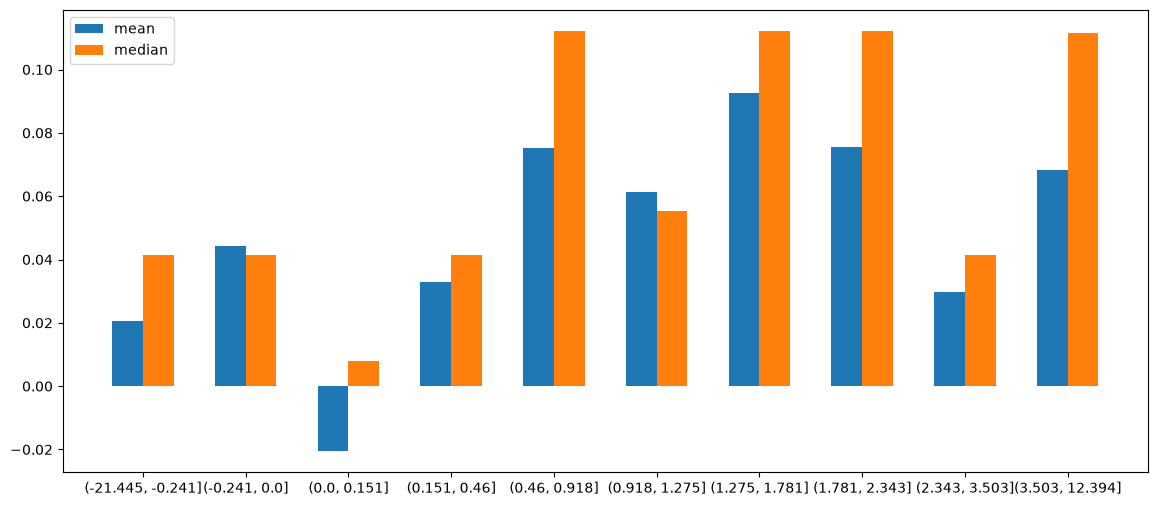

In [60]:
k['sue_decile'] = pd.qcut(k.sue, 10)
means = k.groupby('sue_decile').excess_return.mean()
medians = k.groupby('sue_decile').excess_return.median()

fig, ax = plt.subplots(figsize=(14,6))

ind = np.arange(10)
width = 0.3

ax.bar(ind - 0.15, means, width=0.3, label='mean')
ax.bar(ind + 0.15, medians, width=0.3, label='median')
ax.set_xticks(ind, labels=list(means.index.astype(str)))
ax.legend()

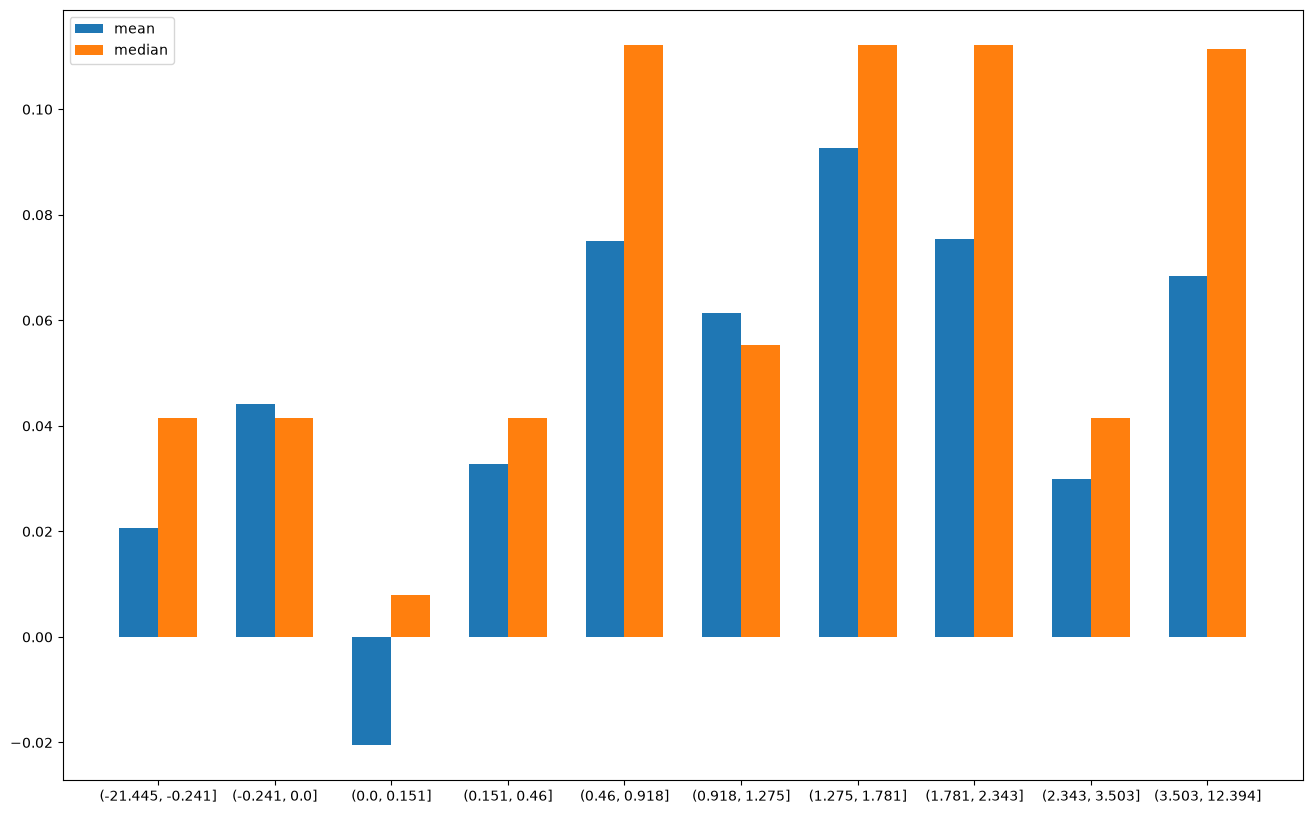

In [ ]:
fig, ax = plt.subplots(figsize=(16,10))


tick_labels = index

vals = {'mean': df_group.mean().values, 'median': df_group.median().values}

res = ax.grouped_bar(vals, tick_labels=index, group_spacing=1)

ax.legend()

In [ ]:
k = requests.get(f'https://financialmodelingprep.com/stable/earnings?symbol=SPCX&apikey={os.getenv('FMP_API_KEY')}')


In [ ]:
market_df = earnings_df.loc[earnings_df['ticker'] == 'IWM']

,ticker,announcement,realized_eps,expected_eps,realized_revenue,expected_revenue,last_updated,is_future,surprise,sue


In [23]:
raw = yf.download('AAPL', start='2024-01-01', end='2024-02-01', auto_adjust=False)
print(raw.columns.get_level_values(0))
print("Type colonnes:", type(raw.columns))
print("Colonnes:", raw.columns.tolist())
print("Après reset_index:", raw.reset_index().columns.tolist())

[*********************100%***********************]  1 of 1 completed

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
Type colonnes: <class 'pandas.MultiIndex'>
Colonnes: [('Adj Close', 'AAPL'), ('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]
Après reset_index: [('index', ''), ('Adj Close', 'AAPL'), ('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]


In [24]:
init_db(db_path)
df = fetch_prices(['AAPL', 'MSFT', 'SOFI', 'LCID', 'GOOG', 'TTE'], start, end)
store_prices(df, db_path)

aapl = query_prices('AAPL', db_path)
lcid = query_prices('LCID', db_path)
print(aapl[['date','close']].head())
print(lcid[['date','close']].head())
# AAPL doit être autour de 180-250$, LCID autour de 2-4$. S'ils sont identiques, bug.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


        date       close
0 2025-01-27  229.860001
1 2025-01-28  238.259995
2 2025-01-31  236.000000
3 2025-02-11  232.619995
4 2025-02-12  236.869995
        date      close
0 2025-01-27  27.500000
1 2025-01-28  27.700001
2 2025-01-31  27.600000
3 2025-02-11  26.900000
4 2025-02-12  28.700001


Loop over tickers, pull each from yfinance, normalize into your chosen long format with consistent column names. Handle the cases where a ticker returns nothing or errors out (one bad ticker shouldn't kill the whole run). Be polite with a small sleep between requests. Heads-up on a real gotcha: recent yfinance versions return a MultiIndex column frame even for a single ticker — you'll need to flatten it, and discovering that yourself by inspecting df.columns is a good exercise.

## The spec — implement these four functions:

init_db(db_path) — connect to DuckDB, create a prices table if it doesn't exist with columns for ticker, date, the OHLC prices, adjusted close, and volume. Decide the primary key. Think about types (what's the right type for volume vs. price?).

fetch_prices(tickers, start, end) -> DataFrame — loop over tickers, pull each from yfinance, normalize into your chosen long format with consistent column names. Handle the cases where a ticker returns nothing or errors out (one bad ticker shouldn't kill the whole run). Be polite with a small sleep between requests. Heads-up on a real gotcha: recent yfinance versions return a MultiIndex column frame even for a single ticker — you'll need to flatten it, and discovering that yourself by inspecting df.columns is a good exercise.

store_prices(df, db_path) — write the dataframe into DuckDB idempotently. Look up how DuckDB lets you query a registered pandas dataframe directly; it's elegant and you'll use the pattern repeatedly.

query_prices(ticker, db_path) -> DataFrame — read one ticker's history back, date-ordered. Use a parameterized query, not string formatting — I want you to build the safe-SQL habit from day one even though this is local.
How to validate your work: write a small script that fetches maybe five tickers (mix a mega-cap like MSFT with something small and volatile like SOFI), stores them, reads one back, and prints the date range and row count. If you can round-trip real data, the layer works.

In [1]:
# init_db

# create a persistent DB

# create prices table : ticker, date, OHLC, adjusted close, volume. Primary key should be (ticket, date) ? or add an ID ?
# volume : int ; price : float


# 6. Ce que tu vas construire cette semaine
L'objectif : une table earnings dans DuckDB, avec une ligne par (ticker, date d'annonce), contenant le BPA réalisé, le BPA estimé, la surprise, et le SUE calculé.
Décisions de conception à trancher avant de coder :
D'abord, le schéma de la table earnings. Réfléchis aux colonnes : ticker, date d'annonce, date de fin de période fiscale (garde-la, utile pour vérifier le décalage), BPA réalisé, BPA estimé, surprise brute, SUE. Pense à la primary key — qu'est-ce qui identifie une ligne de façon unique ?
Ensuite, la source. Je te suggère de commencer avec Finnhub (free tier, inscription gratuite, clé API). Tu fais un appel par ticker sur l'endpoint earnings, tu récupères l'historique trimestriel. Mets ta clé API dans un .env (jamais en dur dans le code — tu as déjà .env dans ton .gitignore, donc utilise python-dotenv pour la charger).
Puis, le calcul du SUE. Pour chaque (ticker, trimestre) : surprise = actual − estimate ; puis SUE = surprise / écart-type des 8 dernières surprises de ce ticker. Attention : le SUE d'un trimestre ne doit utiliser que les surprises passées pour l'écart-type (sinon, encore une fois, look-ahead). C'est un calcul en fenêtre glissante expanding ou rolling sur les données triées par date.
Enfin, la gestion du fallback quand un ticker a moins de 8 trimestres d'historique : soit tu utilises l'écart-type sur ce qui est disponible (avec un minimum, genre 4 trimestres), soit tu bascules sur la division par le prix, soit tu marques le SUE comme non calculable. Choisis et assume.
Le spec des fonctions (à toi de les écrire) :
fetch_earnings(tickers, api_key) → récupère l'historique earnings depuis Finnhub pour chaque ticker, retourne un DataFrame long avec ticker, date d'annonce, période, actual, estimate. Gère le rate-limit (sleep) et les erreurs par ticker comme tu l'as appris.
compute_sue(df) → prend le DataFrame d'earnings, trie par ticker et date, calcule la surprise puis le SUE en fenêtre glissante par ticker (attention au look-ahead dans le calcul de σ). Retourne le DataFrame enrichi.
init_earnings_db(db_path) et store_earnings(df, db_path) → même logique que pour les prix, tu as déjà le pattern.
Avant que tu te lances, trois questions pour vérifier que la théorie est passée :

Pourquoi est-ce qu'on standardise la surprise au lieu d'utiliser la surprise brute en dollars ?
Si une entreprise clôt son trimestre le 30 juin et publie ses résultats le 28 juillet, quelle date utilises-tu comme référence pour ton signal, et pourquoi l'autre serait une erreur ?
Dans le calcul de l'écart-type pour standardiser le SUE du trimestre actuel, pourquoi est-ce que je ne peux pas inclure la surprise du trimestre actuel lui-même dans le calcul de σ ?

Réponds à ces trois-là (briève­ment), et si c'est bon, tu attaques le code. On reste en français.
                        
                        La théorie est solide. Vas-y, code la couche earnings :

init_earnings_db + store_earnings (tu as le pattern des prix).
fetch_earnings(tickers, api_key) via Finnhub, clé dans .env chargée avec python-dotenv, rate-limit géré, erreurs par ticker.
compute_sue(df) : tri par ticker/date, surprise = actual − estimate, σ en rolling 8 trimestres décalé d'un cran (pour exclure le trimestre courant — réfléchis à comment .shift() t'aide ici), SUE = surprise / σ, NA si historique insuffisant.

In [ ]:
df = fetch_earnings(tickers, os.getenv('FMP_API_KEY'))
df = compute_sue(df)


Fetching for AAPL...


In [59]:
print(df[['announcement', 'surprise', 'sue']].tail(20))

   announcement  surprise       sue
19   2021-10-28      0.00  0.000000
18   2022-01-27      0.21  1.633920
17   2022-04-28      0.09  0.706596
16   2022-07-28      0.06  0.462910
15   2022-10-27      0.02  0.148205
14   2023-02-02     -0.05 -0.363591
13   2023-05-04      0.08  0.539226
12   2023-08-03      0.07  0.652443
11   2023-11-02      0.07  0.975426
10   2024-02-01      0.08  1.174955
9    2024-05-02      0.02  0.459588
8    2024-08-01      0.06  1.424765
7    2024-10-31      0.04  0.949843
6    2025-01-30      0.04  0.970589
5    2025-05-01      0.02  0.977356
4    2025-07-31      0.13  5.964809
3    2025-10-30      0.12  3.510108
2    2026-01-29      0.18  4.502199
1    2026-04-30      0.06  1.077903
0    2026-07-30       NaN       NaN


In [314]:
df[df.ticker=='AAPL'][['announcement','realized_eps','expected_eps','surprise']].iloc[-32:-20]

,announcement,realized_eps,expected_eps,surprise
31,2018-11-01,0.73,0.70,0.03
30,2019-01-29,1.04,1.04,0.00
29,2019-04-30,0.62,0.59,0.03
28,2019-07-30,0.55,0.52,0.03
27,2019-10-30,0.76,0.71,0.05
26,2020-01-28,1.25,1.13,0.12
25,2020-04-30,0.64,0.52,0.12
24,2020-07-30,0.64,0.51,0.13
23,2020-10-29,0.73,0.69,0.04
22,2021-01-27,1.68,1.41,0.27


In [315]:
aapl = df[df.ticker=='AAPL'].sort_values('announcement').reset_index(drop=True)
i = aapl.index[aapl.announcement=='2019-04-30'][0]
fenetre = aapl['surprise'].iloc[max(0,i-8):i]
print("fenêtre:", fenetre.values)
print("points non-NaN:", fenetre.notna().sum())
print("sigma pop:", fenetre.std(ddof=0))
print("sue recalc:", aapl['surprise'].iloc[i] / fenetre.std(ddof=0))

fenêtre: [0.02 0.03 0.05 0.02 0.01 0.04 0.03 0.  ]
points non-NaN: 8
sigma pop: 0.014999999999999998
sue recalc: 2.000000000000002


In [287]:
k = fetch_earnings(['AAPL', 'TSLA'], os.getenv('FMP_API_KEY'))

Fetching for AAPL...
Fetching for TSLA...


In [288]:
k = compute_sue(k)
store_earnings(k, '../data/earnings.db')
k

,ticker,announcement,realized_eps,expected_eps,realized_revenue,expected_revenue,last_updated,is_future,surprise,sue
163,AAPL,1985-09-30,0.00161,NaN,4.097000e+08,NaN,2026-03-23,False,NaN,NaN
162,AAPL,1985-12-31,0.00411,NaN,5.339000e+08,NaN,2026-03-23,False,NaN,NaN
161,AAPL,1986-03-31,0.00227,NaN,4.089000e+08,NaN,2026-03-23,False,NaN,NaN
160,AAPL,1986-06-30,0.00227,NaN,4.483000e+08,NaN,2026-03-23,False,NaN,NaN
159,AAPL,1986-09-30,0.00235,NaN,5.108000e+08,NaN,2026-03-23,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2,AAPL,2026-01-29,2.85000,2.6700,1.437560e+11,1.383910e+11,2026-06-04,False,0.1800,4.502199
1,TSLA,2026-04-22,0.41000,0.3539,2.238700e+10,2.210078e+10,2026-06-13,False,0.0561,0.675040
1,AAPL,2026-04-30,2.01000,1.9500,1.111840e+11,1.094576e+11,2026-06-13,False,0.0600,1.077903
0,TSLA,2026-07-22,NaN,0.4500,NaN,2.430876e+10,2026-06-13,True,NaN,NaN


In [289]:
with duckdb.connect('../data/earnings.db') as con:
    n = con.execute('SELECT * from earnings').fetchdf()
n

,announcement,ticker,realized_eps,expected_eps,surprise,sue,expected_revenue,realized_revenue,is_future,last_updated
0,1988-06-30,AAPL,0.00624,NaN,NaN,NaN,NaN,9.931000e+08,False,2026-03-23
1,1988-12-31,AAPL,0.00984,NaN,NaN,NaN,NaN,1.405100e+09,False,2026-03-23
2,1992-06-30,AAPL,0.00964,NaN,NaN,NaN,NaN,1.740200e+09,False,2026-03-23
3,1993-01-16,AAPL,0.01190,NaN,NaN,NaN,NaN,2.000292e+09,False,2026-06-04
4,1994-01-21,AAPL,0.00310,NaN,NaN,NaN,NaN,2.469000e+09,False,2026-06-04
...,...,...,...,...,...,...,...,...,...,...
233,2023-07-19,TSLA,0.91000,0.820,0.090,0.975112,2.447710e+10,2.492700e+10,False,2025-04-25
234,2024-02-01,AAPL,2.18000,2.100,0.080,1.174955,1.179866e+11,1.195750e+11,False,2026-06-04
235,2025-01-29,TSLA,0.73000,0.774,-0.044,-0.556630,2.725892e+10,2.570700e+10,False,2025-04-29
236,2025-01-30,AAPL,2.40000,2.360,0.040,0.970589,1.242574e+11,1.243000e+11,False,2026-06-04


In [4]:
# comment finnhub

finnhub_client = finnhub.Client(api_key=os.getenv('FINNHUB_API_KEY'))

In [ ]:
k = finnhub_client.company_earnings('SPCX', limit=None)

In [11]:
fmp = FMP(api_key=os.getenv('FMP_API_KEY'))

In [219]:
r2

[{'symbol': 'LCID',
  'date': '2026-08-04',
  'epsActual': None,
  'epsEstimated': -2.40034,
  'revenueActual': None,
  'revenueEstimated': 441916700,
  'lastUpdated': '2026-06-13'},
 {'symbol': 'LCID',
  'date': '2026-05-05',
  'epsActual': -3.46,
  'epsEstimated': -2.72,
  'revenueActual': 282465000,
  'revenueEstimated': 358455600,
  'lastUpdated': '2026-06-13'},
 {'symbol': 'LCID',
  'date': '2026-02-24',
  'epsActual': -3.62,
  'epsEstimated': -2.49,
  'revenueActual': 522730000,
  'revenueEstimated': 459530700,
  'lastUpdated': '2026-05-24'},
 {'symbol': 'LCID',
  'date': '2025-11-05',
  'epsActual': -3.31,
  'epsEstimated': -2.32,
  'revenueActual': 336580000,
  'revenueEstimated': 473078750,
  'lastUpdated': '2026-02-05'},
 {'symbol': 'LCID',
  'date': '2025-08-05',
  'epsActual': -2.8,
  'epsEstimated': -2.18,
  'revenueActual': 259432000,
  'revenueEstimated': 259354682,
  'lastUpdated': '2025-11-05'},
 {'symbol': 'LCID',
  'date': '2025-05-06',
  'epsActual': -0.24,
  'epsEs

In [220]:

key = os.getenv('FMP_API_KEY')
# Surprises historiques
url = f"https://financialmodelingprep.com/stable/earnings?symbol=AAPL&apikey={key}"
r2 = requests.get(url).json()
print(len(r2), "trimestres disponibles")
print(r2[:3])

164 trimestres disponibles
[{'symbol': 'AAPL', 'date': '2026-07-30', 'epsActual': None, 'epsEstimated': 1.86, 'revenueActual': None, 'revenueEstimated': 108400600000, 'lastUpdated': '2026-06-13'}, {'symbol': 'AAPL', 'date': '2026-04-30', 'epsActual': 2.01, 'epsEstimated': 1.95, 'revenueActual': 111184000000, 'revenueEstimated': 109457600000, 'lastUpdated': '2026-06-13'}, {'symbol': 'AAPL', 'date': '2026-01-29', 'epsActual': 2.85, 'epsEstimated': 2.67, 'revenueActual': 143756000000, 'revenueEstimated': 138391000000, 'lastUpdated': '2026-06-04'}]


In [225]:
pd.DataFrame(r2).tail(40)

,symbol,date,epsActual,epsEstimated,revenueActual,revenueEstimated,lastUpdated
124,AAPL,1995-07-20,0.00750,0.0075,2.575000e+09,2.575000e+09,2026-06-04
125,AAPL,1995-04-20,0.00530,0.0100,2.652000e+09,2.575000e+09,2026-06-04
126,AAPL,1995-01-19,0.01380,NaN,2.832000e+09,NaN,2026-06-04
127,AAPL,1994-12-13,0.00850,NaN,2.493286e+09,NaN,2026-06-04
128,AAPL,1994-10-17,0.01040,NaN,2.149908e+09,NaN,2026-06-04
129,AAPL,1994-04-21,0.00130,NaN,2.077000e+09,NaN,2026-06-04
130,AAPL,1994-01-21,0.00310,NaN,2.469000e+09,NaN,2026-06-04
131,AAPL,1993-10-15,0.00021,NaN,2.140800e+09,NaN,2026-06-04
132,AAPL,1993-07-16,-0.01450,NaN,1.861979e+09,NaN,2026-06-04
133,AAPL,1993-04-20,0.00820,NaN,1.973900e+09,NaN,2026-06-04


In [194]:
kf = pd.DataFrame(r2)

kf['sue'] = np.nan
kf

,symbol,date,epsActual,epsEstimated,revenueActual,revenueEstimated,lastUpdated,sue
0,LCID,2026-08-04,NaN,-2.40034,NaN,441916700.0,2026-06-13,NaN
1,LCID,2026-05-05,-3.46000,-2.72000,282465000.0,358455600.0,2026-06-13,NaN
2,LCID,2026-02-24,-3.62000,-2.49000,522730000.0,459530700.0,2026-05-24,NaN
3,LCID,2025-11-05,-3.31000,-2.32000,336580000.0,473078750.0,2026-02-05,NaN
4,LCID,2025-08-05,-2.80000,-2.18000,259432000.0,259354682.0,2025-11-05,NaN
5,LCID,2025-05-06,-0.24000,-0.23000,235048000.0,246164380.0,2025-08-06,NaN
6,LCID,2025-02-25,-0.22000,-0.26000,234473000.0,211766140.0,2025-05-25,NaN
7,LCID,2024-11-07,-0.28000,-0.30000,200038000.0,197970000.0,2024-11-08,NaN
8,LCID,2024-08-05,-0.29000,-0.27000,200581000.0,192060000.0,2025-04-25,NaN
9,LCID,2024-05-06,-0.30000,-0.25000,172740000.0,155990000.0,2025-04-25,NaN


In [196]:
kf.epsActual.shift(-1)[::-1].rolling(window=8).std(ddof=0)[::-1]

0      1.535600
1      1.456389
2      1.212930
3      0.836641
4      0.049687
5      0.064505
6      0.059987
7      0.059674
8      0.056111
9      0.115515
10     0.115731
11     0.116344
12     0.129204
13     4.048253
14    10.119369
15     9.930750
16     9.938244
17     9.740299
18          NaN
19          NaN
20          NaN
21          NaN
22          NaN
23          NaN
24          NaN
25          NaN
Name: epsActual, dtype: float64